In [2]:
import easyocr

reader = easyocr.Reader(["en"])

result = reader.readtext(r"C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\train\images\Cars0.png")

for detection in result:
    bbox, text, confidence = detection
    print(text, confidence)


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


KLo1CA2555 0.17873455858873255


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


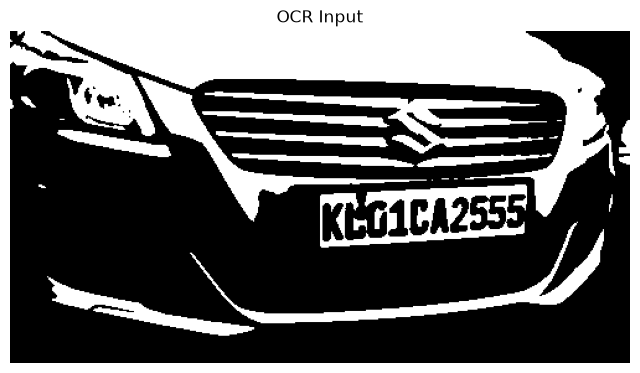

In [5]:
import cv2
import matplotlib.pyplot as plt

# 1. Load image
image = cv2.imread(r"C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\train\images\Cars0.png")

# 2. Preprocess
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Display with Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')
plt.title("OCR Input")
plt.axis('off')  # Hide axis ticks
plt.show()

Using CPU. Note: This module is much faster with a GPU.
c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


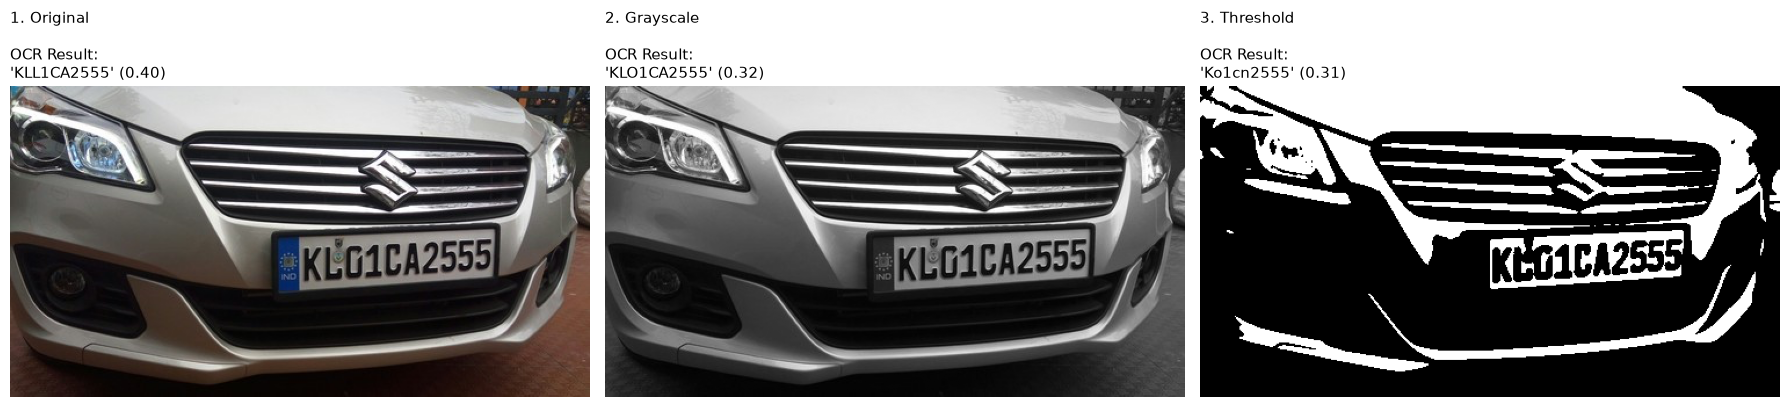

In [6]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# 1. Initialize EasyOCR Reader (gpu=False to suppress CUDA warning if no GPU)
reader = easyocr.Reader(['en'], gpu=False)

# 2. Define Image Path
img_path = r"C:\Users\PC-LAB1\img_processing_lab\License-Plate-Data\train\images\Cars0.png"

# 3. Step-by-Step Processing
# Stage 1: Original Image
orig_bgr = cv2.imread(img_path)
orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)  # Convert for Matplotlib display

# Stage 2: Grayscale
gray = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2GRAY)

# Stage 3: Thresholding (Otsu's Binarization with Gaussian Blur)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresholded = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. Stage 4: Run OCR on Each Stage
def get_ocr_text(img_input):
    results = reader.readtext(img_input)
    if not results:
        return "No text detected"
    # Join all detected text segments into a single string with confidence score
    return "\n".join([f"'{text}' ({conf:.2f})" for _, text, conf in results])

ocr_orig = get_ocr_text(orig_bgr)
ocr_gray = get_ocr_text(gray)
ocr_thresh = get_ocr_text(thresholded)

# 5. Visual Comparison Layout using Matplotlib
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Original
axes[0].imshow(orig_rgb)
axes[0].set_title(f"1. Original\n\nOCR Result:\n{ocr_orig}", fontsize=11, loc='left')
axes[0].axis('off')

# Plot 2: Grayscale
axes[1].imshow(gray, cmap='gray')
axes[1].set_title(f"2. Grayscale\n\nOCR Result:\n{ocr_gray}", fontsize=11, loc='left')
axes[1].axis('off')

# Plot 3: Thresholded
axes[2].imshow(thresholded, cmap='gray')
axes[2].set_title(f"3. Threshold\n\nOCR Result:\n{ocr_thresh}", fontsize=11, loc='left')
axes[2].axis('off')

plt.tight_layout()
plt.show()